<a href="https://colab.research.google.com/github/Yasinnn7/CODSOFT-ML/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_test=pd.read_csv('/content/test_data.txt', sep=':::', header=None, engine='python')
df_train=pd.read_csv('/content/train_data.txt', sep=':::', header=None, engine='python')
df_test.columns=["SN", "Movie_Names", "Reviews"]
df_train.columns=["SN", "Movie_Names", "Category", "Reviews"]


In [3]:
df_train.head()

,SN,Movie_Names,Category,Reviews
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [4]:
df_test.head()

,SN,Movie_Names,Reviews
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),Before he was known internationally as a mart...


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SN           54214 non-null  int64 
 1   Movie_Names  54214 non-null  object
 2   Category     54214 non-null  object
 3   Reviews      54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54200 entries, 0 to 54199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SN           54200 non-null  int64 
 1   Movie_Names  54200 non-null  object
 2   Reviews      54200 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [7]:
df_train.describe()

,SN
count,54214.000000
mean,27107.500000
std,15650.378084
min,1.000000
25%,13554.250000
50%,27107.500000
75%,40660.750000
max,54214.000000


In [8]:
df_test.describe()

,SN
count,54200.000000
mean,27100.500000
std,15646.336632
min,1.000000
25%,13550.750000
50%,27100.500000
75%,40650.250000
max,54200.000000


In [9]:
df_train.isnull().sum()

,0
SN,0
Movie_Names,0
Category,0
Reviews,0


In [10]:
df_test.isnull().sum()

,0
SN,0
Movie_Names,0
Reviews,0


In [11]:
df_train.shape

(54214, 4)

In [12]:
df_test.shape

(54200, 3)

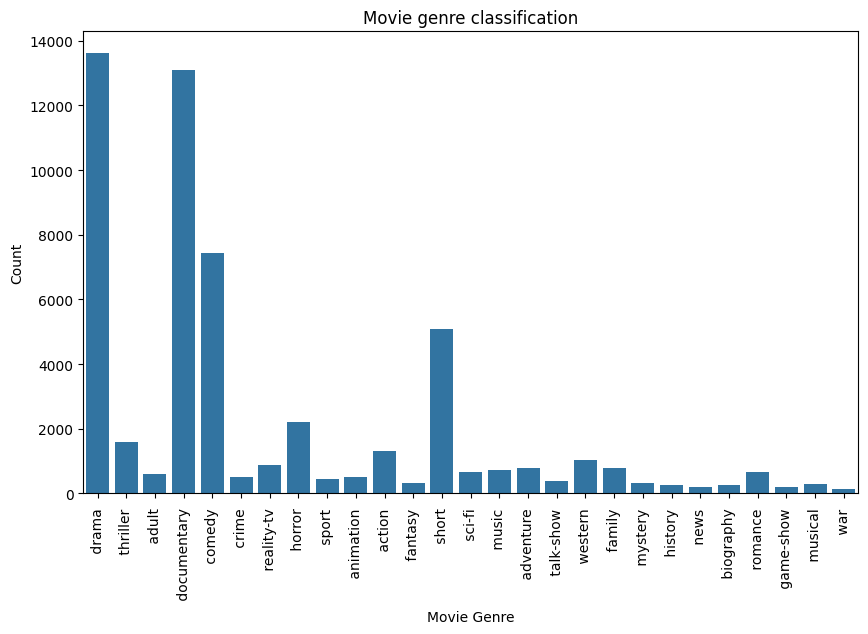

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df_train)
plt.title("Movie genre classification")
plt.xlabel("Movie Genre")
plt.ylabel("Count")
plt.xticks(rotation=90);
plt.show()

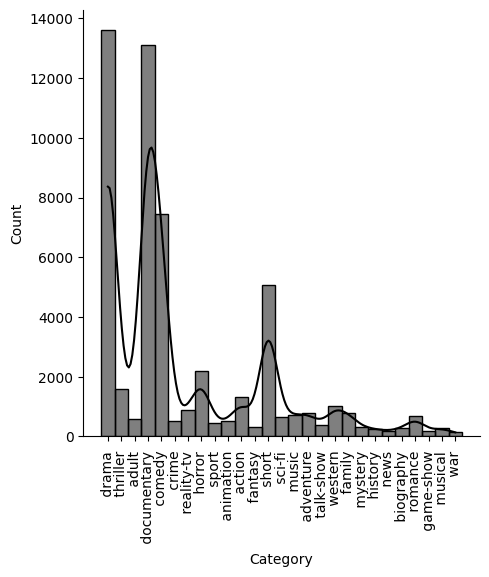

In [14]:

sns.displot(df_train.Category,  kde=True, color='Black')
plt.xticks(rotation=90);
plt.show()


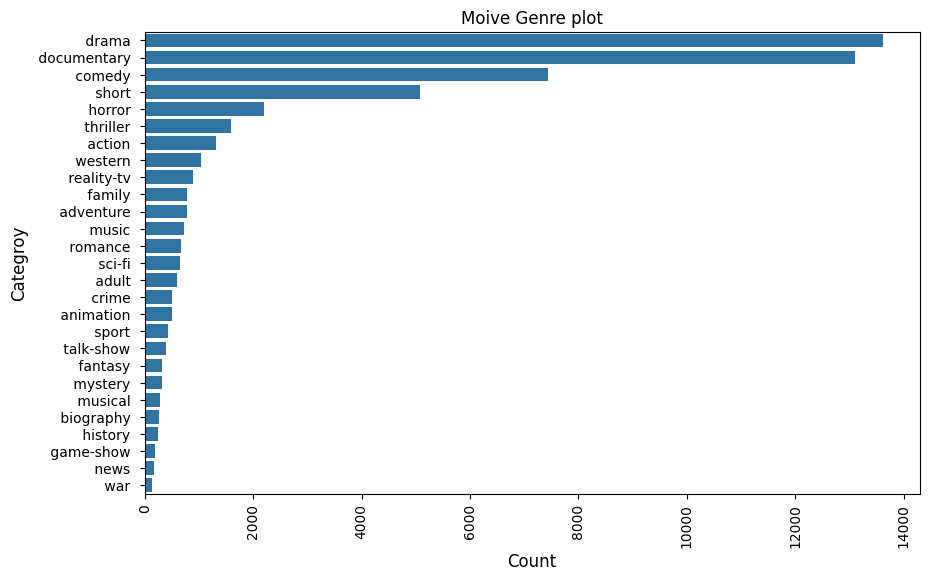

In [15]:
plt.figure(figsize=(10,6))
count1=df_train.Category.value_counts()
sns.barplot(x=count1, y=count1.index, orient='h')
plt.ylabel('Categroy', fontsize=12)
plt.xlabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.title('Moive Genre plot')
plt.show();


In [16]:
df_combined= pd.concat([df_train, df_test])
df_combined.head()

,SN,Movie_Names,Category,Reviews
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [17]:
df_combined.shape

(108414, 4)

In [18]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108414 entries, 0 to 54199
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   SN           108414 non-null  int64 
 1   Movie_Names  108414 non-null  object
 2   Category     54214 non-null   object
 3   Reviews      108414 non-null  object
dtypes: int64(1), object(3)
memory usage: 4.1+ MB


In [19]:
df_combined.size

433656

In [20]:
df_combined.isnull().any()

,0
SN,False
Movie_Names,False
Category,True
Reviews,False


In [21]:
df_combined.count()

,0
SN,108414
Movie_Names,108414
Category,54214
Reviews,108414


In [22]:
df_combined.isnull().sum()

,0
SN,0
Movie_Names,0
Category,54200
Reviews,0


In [23]:
lr=LabelEncoder()
df_combined['Category']=lr.fit_transform(df_combined['Category'].values)
df_combined['Moive_Names']=lr.fit_transform(df_combined['Movie_Names'].values)
df_combined.head()

,SN,Movie_Names,Category,Reviews,Moive_Names
0,1,Oscar et la dame rose (2009),8,Listening in to a conversation between his do...,70147
1,2,Cupid (1997),24,A brother and sister with a past incestuous r...,31219
2,3,"Young, Wild and Wonderful (1980)",1,As the bus empties the students for their fie...,107508
3,4,The Secret Sin (1915),8,To help their unemployed father make ends mee...,96121
4,5,The Unrecovered (2007),8,The film's title refers not only to the un-re...,97559


In [24]:
df_combined.Category=df_combined.Category.fillna(df_combined.Category.mean())
df_combined.count()

,0
SN,108414
Movie_Names,108414
Category,108414
Reviews,108414
Moive_Names,108414


In [25]:
df_combined.duplicated().values.any()


np.False_

# Preprocess the data

In [26]:
vector=TfidfVectorizer()
x=vector.fit_transform(df_combined['Reviews'])
y=df_combined['Category']
df_combined.head()


,SN,Movie_Names,Category,Reviews,Moive_Names
0,1,Oscar et la dame rose (2009),8,Listening in to a conversation between his do...,70147
1,2,Cupid (1997),24,A brother and sister with a past incestuous r...,31219
2,3,"Young, Wild and Wonderful (1980)",1,As the bus empties the students for their fie...,107508
3,4,The Secret Sin (1915),8,To help their unemployed father make ends mee...,96121
4,5,The Unrecovered (2007),8,The film's title refers not only to the un-re...,97559


# Train Test Split

In [27]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

# Train Naive bayes Classifier

In [28]:
Naive_bayes_model=MultinomialNB()

In [29]:
Naive_bayes_model.fit(x_train, y_train)

MultinomialNB()

In [30]:
NB_prediction=Naive_bayes_model.predict(x_test)

In [31]:
print("Naive Bayes Model: ")
print(confusion_matrix(y_test, NB_prediction))
print(classification_report(y_test, NB_prediction))
print(accuracy_score(y_test, NB_prediction))
print("r2_Score", r2_score(y_test, NB_prediction))

Naive Bayes Model: 
[[    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0   267]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0   115]
 [    0     0     0     0     0     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0   163]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0   100]
 [    0     0     0     0     0     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0    54]
 [    0     0     0     0     0    10     0     0     3     0     0     0
      0     0     0     0     0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
logic_model=LogisticRegression()
logic_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
lr_prediction=logic_model.predict(x_test)

In [34]:
print("Logistic Regression Model: ")
print(confusion_matrix(y_test, lr_prediction))
print(classification_report(y_test, lr_prediction))
print(accuracy_score(y_test, lr_prediction))
print("r2_Score", r2_score(y_test, lr_prediction))

Logistic Regression Model: 
[[   0    0    0    0    0    0    0    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0  265]
 [   0    1    0    0    0    1    0    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0  112]
 [   0    0    1    0    0    1    0    1    0    0    0    0    0    0
     0    0    0    0    1    0    0    0    0    0    0    0    0  161]
 [   0    0    0    0    0    3    0    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0   96]
 [   0    0    0    0    0    0    0    9    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0   45]
 [   0    0    0    0    0  103    0    3   16    0    0    0    0    1
     0    0    0    0    0    1    1    0    0    0    0    0    0 1363]
 [   0    0    0    0    0    0    0    2    4    0    0    0    0    0
     0    0    0    0    0    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
